
# Prediction vs Causality: Why Your ML Model Can't Tell You What to Do
A gradient boosting model assigns education a feature importance of 74.6% — the #1 predictor of wages.
Does that mean more education *causes* higher wages? This notebook shows why that conclusion is wrong, and what proper causal methods reveal instead.

**Data:** CPS ASEC 2023 via IPUMS — 32,613 prime-age US wage/salary workers

**Methods:** Gradient Boosting, OLS, Propensity Score Matching 

**Key finding:** The raw 55% Bachelor's wage premium reflects *who goes to college*, not just what college does.

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import os
import shutil
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

from scipy.spatial.distance import cdist
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

warnings.filterwarnings('ignore')
os.makedirs('figures', exist_ok=True)

# Plot styling
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titleweight': 'bold',
    'axes.titlesize': 12,
    'figure.dpi': 130,
})

## Section 1: Data Cleaning and Exploratory Analysis
We load the CPS ASEC 2023 data and filter to prime-age (25–55) wage and salary workers with valid wage and hours information. We construct an hourly wage from annual earnings and hours worked, then apply the log transformation standard in labor economics.

In [2]:
 #── Load and prepare raw data ─────────────────────────────────────────────────
df = pd.read_csv("School_data.csv")
df24 = df[df['year'] == 2024].copy()

# Handle IPUMS special codes
df24.loc[df24['age'] == 'Under 1 year', 'age'] = '0'
df24.loc[df24['incwage'] == 'NIU', 'incwage'] = '999999'
df24['age'] = pd.to_numeric(df24['age'])
df24['incwage'] = pd.to_numeric(df24['incwage'])

# ── Filter to prime-age wage/salary workers ───────────────────────────────────
# classwkr: private wage/salary workers only
# incwage: 999999 = missing; 0 = no wage income
# uhrsworkly: 999 = not in universe
df_clean = df24[
    (df24['age'] >= 25) & (df24['age'] <= 55) &
    (df24['classwkr'] == 'Wage/salary, private') &
    (df24['incwage'] > 0) & (df24['incwage'] < 999999) &
    (df24['uhrsworkly'] < 999) & (df24['uhrsworkly'] > 0) &
    (df24['wkswork2'] != 'NIU')
].copy()

print(f"Rows after filtering: {len(df_clean):,}  (from {len(df24):,} original)")

# ── Construct hourly wage ─────────────────────────────────────────────────────
# wkswork2 is bracketed — map to midpoints
wks_map = {
    '1-13 weeks': 7,
    '14-26 weeks': 20,
    '27-39 weeks': 33,
    '40-47 weeks': 43.5,
    '48-49 weeks': 48.5,
    '50-52 weeks': 51,
}
df_clean['weeks_worked'] = df_clean['wkswork2'].map(wks_map)
df_clean['annual_hours'] = df_clean['weeks_worked'] * df_clean['uhrsworkly']
df_clean['hourly_wage'] = df_clean['incwage'] / df_clean['annual_hours']

# Drop implausible hourly wages (below $2 or above $500)
df_clean = df_clean[df_clean['hourly_wage'].between(2, 500)]
print(f"Rows after wage filter: {len(df_clean):,}")

# Log wage — standard in labor economics (Mincer 1974)
df_clean['log_wage'] = np.log(df_clean['hourly_wage'])

# ── Education: map IPUMS labels to years of schooling ────────────────────────
educ_map = {
    'None or preschool': 0,
    'Grades 1, 2, 3, or 4': 4,
    'Grades 5 or 6': 6,
    'Grades 7 or 8': 8,
    'Grade 9': 9,
    'Grade 10': 10,
    'Grade 11': 11,
    '12th grade, no diploma': 11,
    'High school diploma or equivalent': 12,
    'Some college but no degree': 13,
    "Associate's degree, occupational/vocational program": 13,
    "Associate's degree, academic program ": 13,
    "Bachelor's degree": 16,
    "Master's degree": 18,
    'Professional school degree': 18,
    'Doctorate degree': 20,
}
df_clean['educ_years'] = df_clean['educ'].map(educ_map)
df_clean = df_clean.dropna(subset=['educ_years'])
print(f"Rows after education mapping: {len(df_clean):,}")

# ── Mincer experience proxy: age - education - 6 ─────────────────────────────
df_clean['experience'] = (df_clean['age'] - df_clean['educ_years'] - 6).clip(lower=0)
df_clean['experience_sq'] = df_clean['experience'] ** 2

# ── Binary indicator variables ────────────────────────────────────────────────
df_clean['female'] = (df_clean['sex'] == 'Female').astype(int)
df_clean['nonwhite'] = (df_clean['race'] != 'White').astype(int)
df_clean['hispanic'] = (df_clean['hispan'] != 'Not Hispanic').astype(int)
df_clean['married'] = df_clean['marst'].str.contains('married', case=False).astype(int)

print(f"\n── Final dataset ──")
print(f"Observations: {len(df_clean):,}")
print(df_clean[['log_wage', 'hourly_wage', 'educ_years', 'experience', 'female', 'nonwhite']].describe().round(2))

Rows after filtering: 35,000  (from 1,331,621 original)
Rows after wage filter: 34,874
Rows after education mapping: 32,613

── Final dataset ──
Observations: 32,613
       log_wage  hourly_wage  educ_years  experience    female  nonwhite
count  32613.00     32613.00    32613.00    32613.00  32613.00  32613.00
mean       3.37        37.57       14.11       19.39      0.46      0.23
std        0.69        33.64        2.86        9.09      0.50      0.42
min        0.69         2.00        0.00        0.00      0.00      0.00
25%        2.93        18.75       12.00       12.00      0.00      0.00
50%        3.33        27.94       13.00       19.00      0.00      0.00
75%        3.80        44.82       16.00       27.00      1.00      0.00
max        6.19       490.20       20.00       49.00      1.00      1.00


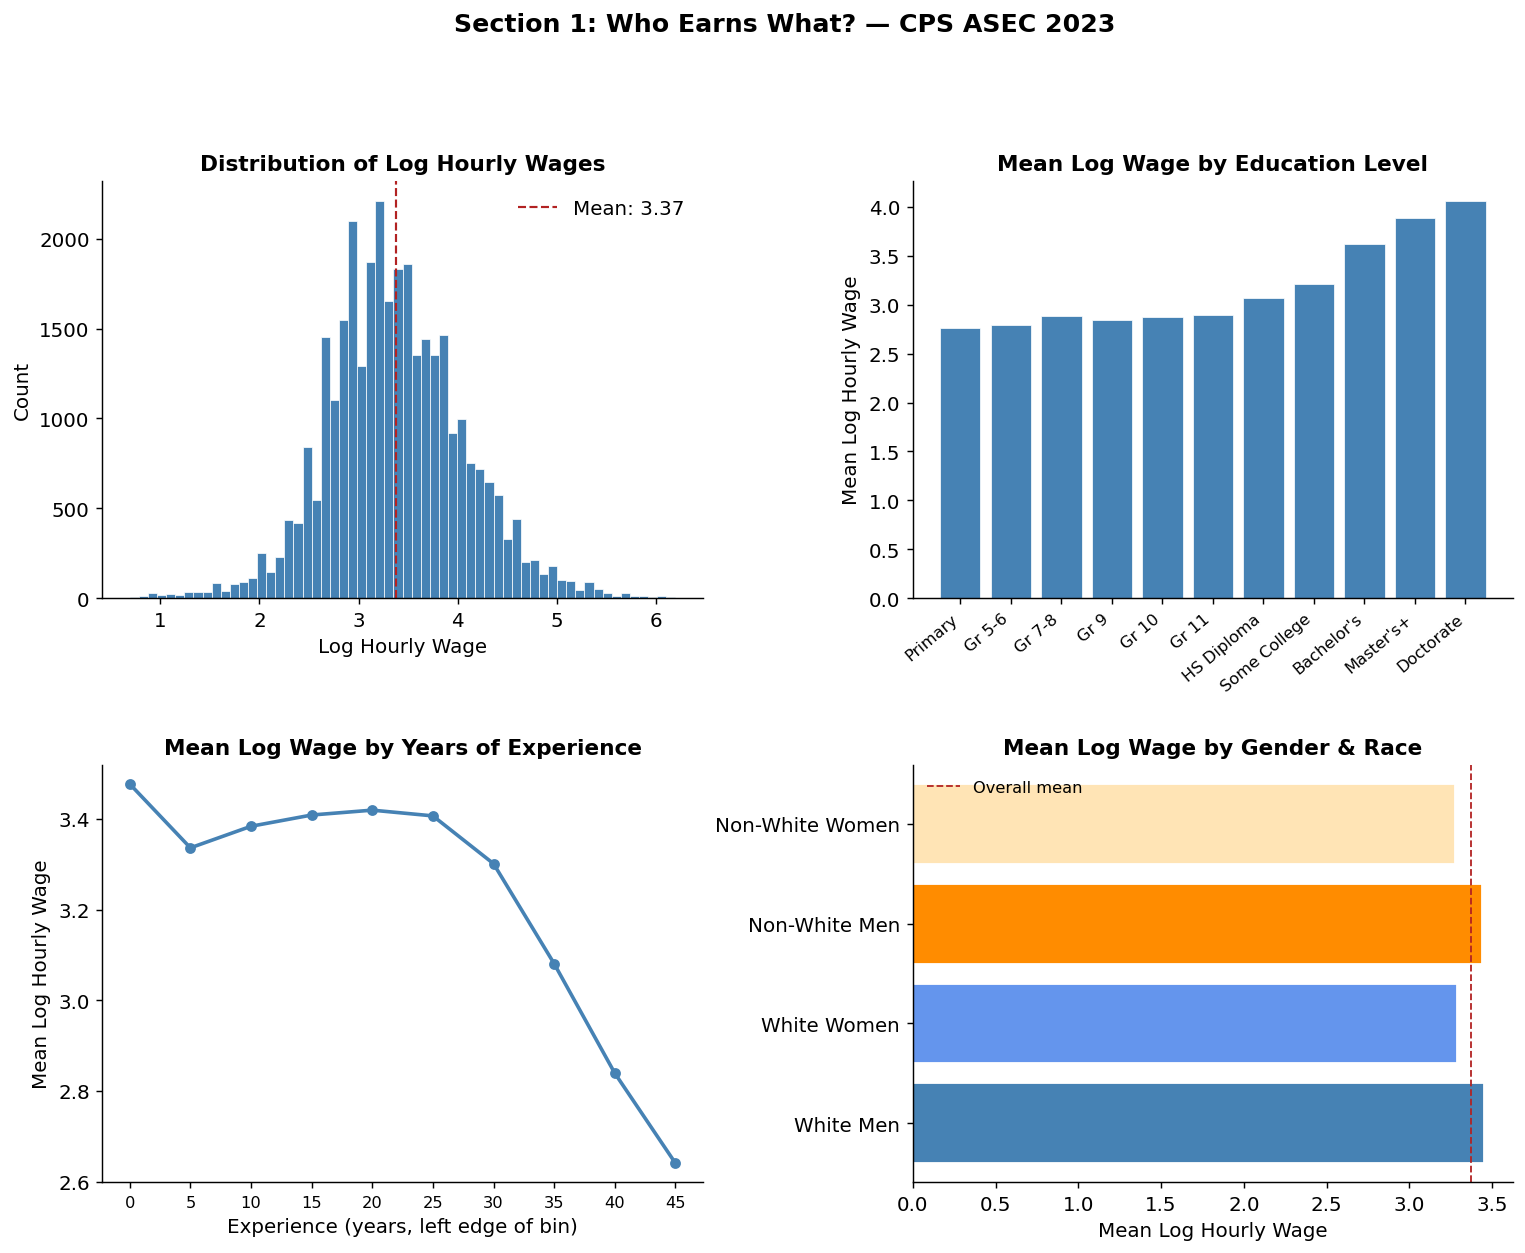

In [3]:
# ── EDA: Four charts telling the wage story ───────────────────────────────────
educ_labels = {
    0: 'None', 4: 'Primary', 6: 'Gr 5-6', 8: 'Gr 7-8',
    9: 'Gr 9', 10: 'Gr 10', 11: 'Gr 11', 12: 'HS Diploma',
    13: 'Some College', 16: "Bachelor's", 18: "Master's+", 20: 'Doctorate',
}
df_clean['educ_label'] = df_clean['educ_years'].map(educ_labels)

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Chart 1: Log wage distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df_clean['log_wage'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax1.axvline(df_clean['log_wage'].mean(), color='firebrick', linestyle='--',
            linewidth=1.2, label=f"Mean: {df_clean['log_wage'].mean():.2f}")
ax1.set_title('Distribution of Log Hourly Wages')
ax1.set_xlabel('Log Hourly Wage')
ax1.set_ylabel('Count')
ax1.legend(frameon=False)

# Chart 2: Mean log wage by education level
ax2 = fig.add_subplot(gs[0, 1])
educ_order = sorted(df_clean['educ_years'].unique())
educ_means = df_clean.groupby('educ_years')['log_wage'].mean()
educ_counts = df_clean.groupby('educ_years')['log_wage'].count()
educ_order = [e for e in educ_order if educ_counts.get(e, 0) > 100]
ax2.bar(range(len(educ_order)), [educ_means[e] for e in educ_order],
        color='steelblue', edgecolor='white', linewidth=0.4)
ax2.set_xticks(range(len(educ_order)))
ax2.set_xticklabels([educ_labels.get(e, str(e)) for e in educ_order],
                    rotation=40, ha='right', fontsize=9)
ax2.set_title('Mean Log Wage by Education Level')
ax2.set_ylabel('Mean Log Hourly Wage')

# Chart 3: Wage by experience (Mincer curve)
ax3 = fig.add_subplot(gs[1, 0])
df_clean['exp_bin'] = pd.cut(df_clean['experience'], bins=range(0, 52, 5))
exp_means = df_clean.groupby('exp_bin', observed=True)['log_wage'].mean()
ax3.plot(range(len(exp_means)), exp_means.values, marker='o',
         color='steelblue', linewidth=2, markersize=5)
ax3.set_xticks(range(len(exp_means)))
ax3.set_xticklabels([str(b.left) for b in exp_means.index], fontsize=9)
ax3.set_title('Mean Log Wage by Years of Experience')
ax3.set_xlabel('Experience (years, left edge of bin)')
ax3.set_ylabel('Mean Log Hourly Wage')

# Chart 4: Gender and race wage gaps
ax4 = fig.add_subplot(gs[1, 1])
groups = {
    'White Men':      df_clean[(df_clean['female']==0) & (df_clean['nonwhite']==0)]['log_wage'].mean(),
    'White Women':    df_clean[(df_clean['female']==1) & (df_clean['nonwhite']==0)]['log_wage'].mean(),
    'Non-White Men':  df_clean[(df_clean['female']==0) & (df_clean['nonwhite']==1)]['log_wage'].mean(),
    'Non-White Women':df_clean[(df_clean['female']==1) & (df_clean['nonwhite']==1)]['log_wage'].mean(),
}
ax4.barh(list(groups.keys()), list(groups.values()),
         color=['steelblue', 'cornflowerblue', 'darkorange', 'moccasin'], edgecolor='white')
ax4.set_title('Mean Log Wage by Gender & Race')
ax4.set_xlabel('Mean Log Hourly Wage')
ax4.axvline(df_clean['log_wage'].mean(), color='firebrick',
            linestyle='--', linewidth=1, label='Overall mean')
ax4.legend(frameon=False, fontsize=9)

fig.suptitle('Section 1: Who Earns What? — CPS ASEC 2023',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('figures/section1_eda.png', bbox_inches='tight', dpi=130)
plt.show()

## Section 2: The ML Model — Good at Predicting, Dangerous for Policy

We train a gradient boosting model to predict log wages. The model achieves R²=0.30,
reasonable for wage data with 7 features. The key result: education dominates feature
importances at 74.6%. A naive reading says education is the main driver of wages.
The next two sections show why acting on that reading would be a mistake.

R²:   0.300
RMSE: 0.581 (log wage units)

Feature importances:
educ_years       0.746
female           0.084
experience       0.053
experience_sq    0.048
hispanic         0.038
nonwhite         0.020
married          0.011
dtype: float64


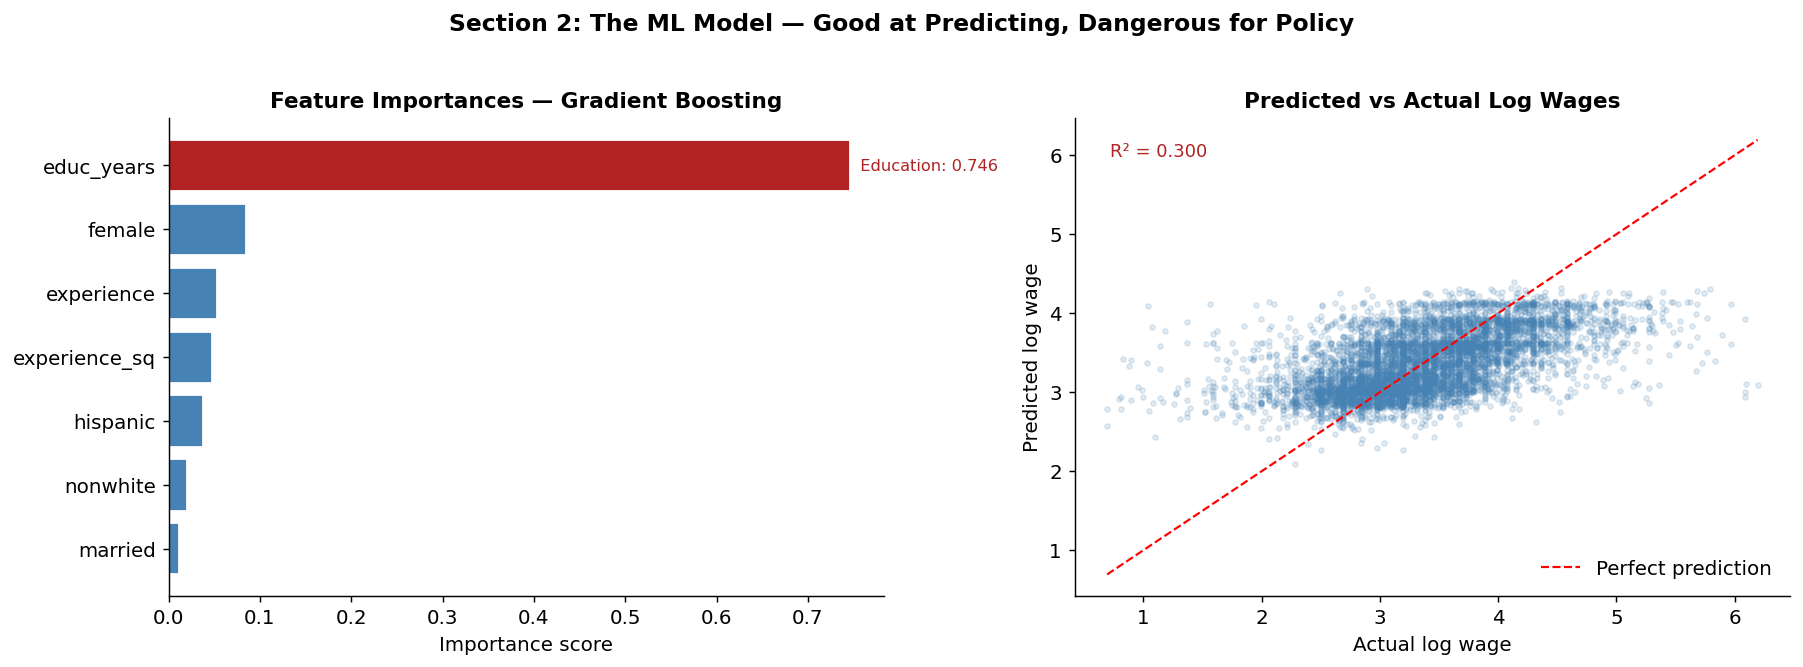

In [4]:

# ── Train gradient boosting model ────────────────────────────────────────────
features = ['educ_years', 'experience', 'experience_sq',
            'female', 'nonwhite', 'hispanic', 'married']

X = df_clean[features]
y = df_clean['log_wage']
w = df_clean['asecwt']

X_train, X_test, y_train, y_test, w_train, w_test = train_test_split(
    X, y, w, test_size=0.2, random_state=42
)

gb_model = GradientBoostingRegressor(
    n_estimators=300, max_depth=4,
    learning_rate=0.05, subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train, sample_weight=w_train)

y_pred = gb_model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R²:   {r2:.3f}")
print(f"RMSE: {rmse:.3f} (log wage units)")

importances = pd.Series(gb_model.feature_importances_, index=features).sort_values(ascending=False)
print(f"\nFeature importances:\n{importances.round(3)}")

# ── Visualize model performance and feature importances ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
imp_sorted = importances.sort_values()
colors = ['firebrick' if i == 'educ_years' else 'steelblue' for i in imp_sorted.index]
ax.barh(imp_sorted.index, imp_sorted.values, color=colors, edgecolor='white')
ax.set_title('Feature Importances — Gradient Boosting', fontweight='bold')
ax.set_xlabel('Importance score')
ax.annotate(f"  Education: {importances['educ_years']:.3f}",
            xy=(importances['educ_years'],
                list(imp_sorted.index).index('educ_years')),
            fontsize=9, color='firebrick', va='center')

ax2 = axes[1]
ax2.scatter(y_test, y_pred, alpha=0.15, s=8, color='steelblue')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=1.2, label='Perfect prediction')
ax2.set_title('Predicted vs Actual Log Wages', fontweight='bold')
ax2.set_xlabel('Actual log wage')
ax2.set_ylabel('Predicted log wage')
ax2.legend(frameon=False)
ax2.text(0.05, 0.92, f'R² = {r2:.3f}', transform=ax2.transAxes,
         fontsize=10, color='firebrick')

plt.suptitle('Section 2: The ML Model — Good at Predicting, Dangerous for Policy',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/section2_ml_model.png', bbox_inches='tight', dpi=130)
plt.show()

## Section 3: Why the ML Answer Misleads — Omitted Variable Bias

If education truly *causes* higher wages, its OLS coefficient should shrink dramatically
as we control for confounders (ability, background). We test this by adding controls
progressively. The coefficient barely moves — not because confounding is small, but because
the key confounders (ability, family wealth) are **not in our dataset**.
Observable controls cannot fix unobservable bias.

── Education coefficient across models ──
  Bivariate            β = 0.1159  → 11.6% per year of education
  + Experience         β = 0.1256  → 12.6% per year of education
  Full controls        β = 0.1244  → 12.4% per year of education


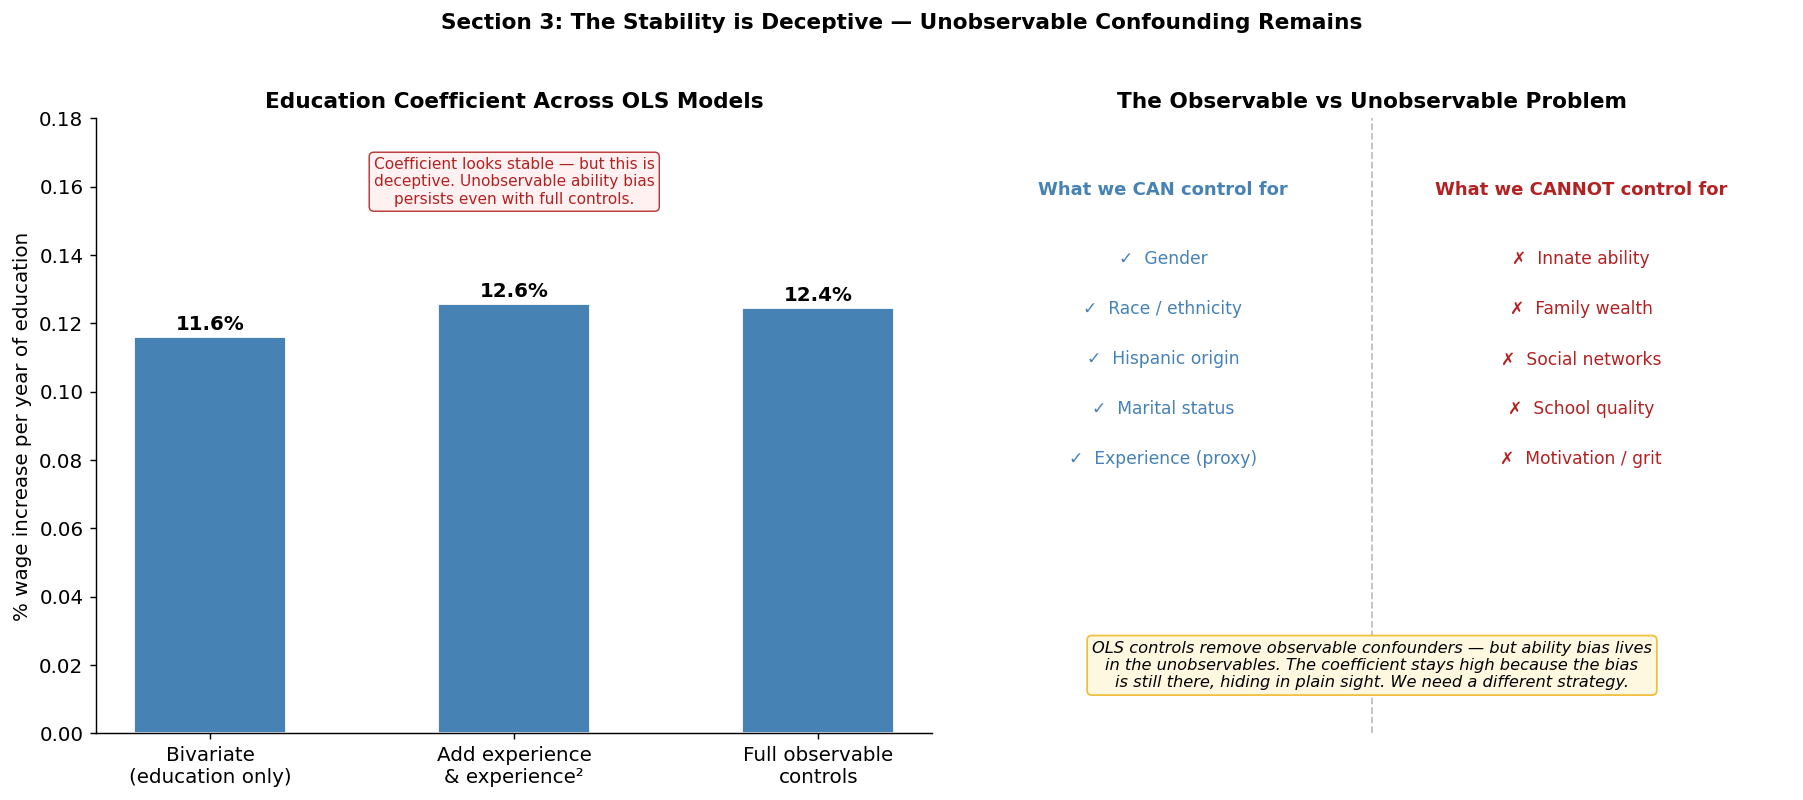

In [5]:

# ── OLS coefficient stability across models ───────────────────────────────────
m1 = sm.WLS(df_clean['log_wage'],
            sm.add_constant(df_clean[['educ_years']]),
            weights=df_clean['asecwt']).fit()

m2 = sm.WLS(df_clean['log_wage'],
            sm.add_constant(df_clean[['educ_years', 'experience', 'experience_sq']]),
            weights=df_clean['asecwt']).fit()

m3 = sm.WLS(df_clean['log_wage'],
            sm.add_constant(df_clean[['educ_years', 'experience', 'experience_sq',
                                      'female', 'nonwhite', 'hispanic', 'married']]),
            weights=df_clean['asecwt']).fit()

print("── Education coefficient across models ──")
for label, model in [('Bivariate', m1), ('+ Experience', m2), ('Full controls', m3)]:
    b = model.params['educ_years']
    print(f"  {label:<20} β = {b:.4f}  → {b*100:.1f}% per year of education")

# ── Plot 1: Coefficient stability ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ax1 = axes[0]

labels = ['Bivariate\n(education only)', 'Add experience\n& experience²',
          'Full observable\ncontrols']
values = [m1.params['educ_years'], m2.params['educ_years'], m3.params['educ_years']]

ax1.bar(labels, values, color=['steelblue', 'steelblue', 'steelblue'],
        edgecolor='white', width=0.5)
for i, (label, val) in enumerate(zip(labels, values)):
    ax1.text(i, val + 0.001, f'{val*100:.1f}%', ha='center',
             va='bottom', fontsize=11, fontweight='bold')

ax1.set_ylim(0, 0.18)
ax1.set_title('Education Coefficient Across OLS Models', fontweight='bold')
ax1.set_ylabel('% wage increase per year of education')
ax1.text(1, 0.155,
         'Coefficient looks stable — but this is\ndeceptive. Unobservable ability bias\n'
         'persists even with full controls.',
         ha='center', fontsize=8.5, color='firebrick',
         bbox=dict(boxstyle='round', facecolor='#fff0f0',
                   edgecolor='firebrick', linewidth=0.8, alpha=0.9))

# ── Plot 2: Observable vs unobservable problem ────────────────────────────────
ax2 = axes[1]
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 8)
ax2.set_title('The Observable vs Unobservable Problem', fontweight='bold')

ax2.text(2.5, 7, 'What we CAN control for', ha='center', fontsize=10,
         fontweight='bold', color='steelblue')
for i, item in enumerate(['Gender', 'Race / ethnicity', 'Hispanic origin',
                           'Marital status', 'Experience (proxy)']):
    ax2.text(2.5, 6.1 - i*0.65, f'✓  {item}', ha='center', fontsize=9.5, color='steelblue')

ax2.text(7.5, 7, 'What we CANNOT control for', ha='center', fontsize=10,
         fontweight='bold', color='firebrick')
for i, item in enumerate(['Innate ability', 'Family wealth', 'Social networks',
                           'School quality', 'Motivation / grit']):
    ax2.text(7.5, 6.1 - i*0.65, f'✗  {item}', ha='center', fontsize=9.5, color='firebrick')

ax2.axvline(5, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax2.text(5, 0.6,
         'OLS controls remove observable confounders — but ability bias lives\n'
         'in the unobservables. The coefficient stays high because the bias\n'
         'is still there, hiding in plain sight. We need a different strategy.',
         ha='center', fontsize=9, style='italic',
         bbox=dict(boxstyle='round', facecolor='#fff8e1', edgecolor='#f0c040', linewidth=1))

plt.suptitle('Section 3: The Stability is Deceptive — Unobservable Confounding Remains',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/section3_confounding_v2.png', bbox_inches='tight', dpi=130)
plt.show()

## Section 4: Propensity Score Matching — And Where It Hits Its Limits

We compare Bachelor's degree holders vs HS diploma holders matched on all observable
characteristics (experience, gender, race, etc.) using propensity score matching.
The matched estimate is virtually identical to the naive gap — because selection into
college is driven by unobservables that matching cannot balance.

This is not a failure — it *is* the finding. It demonstrates exactly why this
identification problem requires instruments (IV) or regression discontinuity designs.

Treatment group (Bachelor's): 9,330
Control group  (HS Diploma):  9,216
Matched pairs: 9,216

── Balance check (|diff| < 0.1 = well balanced) ──
  experience       before: -0.469   after: -0.452  ⚠
  female           before: +0.220   after: +0.208  ⚠
  nonwhite         before: -0.006   after: +0.001  ✓
  hispanic         before: -0.397   after: -0.392  ⚠
  married          before: +0.170   after: +0.167  ⚠

── Causal Estimate ──────────────────────────────────────────────
  Naive raw gap:   54.9%
  Matched ATT:     55.1%  (95% CI: [53.5%, 56.8%])
  Bias removed:    -0.3 percentage points

  → Balance barely improves. Selection into college is driven by
    unobservables. This method cannot solve the identification problem.


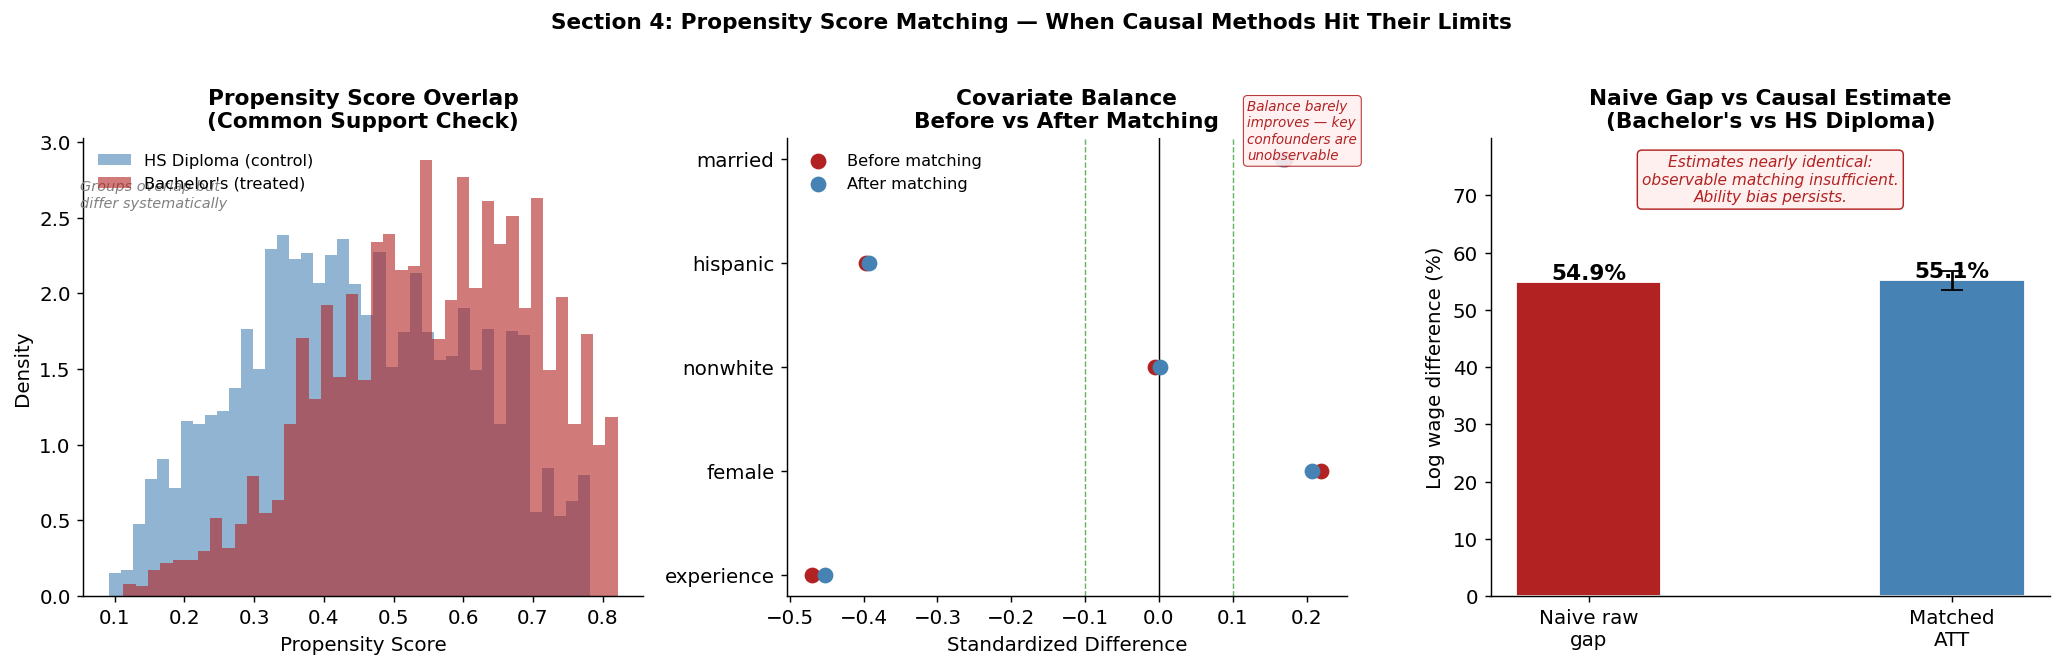

In [6]:

# ── Define treatment: Bachelor's (16 yrs) vs HS diploma (12 yrs) ─────────────
df_ps = df_clean[df_clean['educ_years'].isin([12, 16])].copy()
df_ps['treated'] = (df_ps['educ_years'] == 16).astype(int)

print(f"Treatment group (Bachelor's): {df_ps['treated'].sum():,}")
print(f"Control group  (HS Diploma):  {(1-df_ps['treated']).sum():,}")

# ── Step 1: Estimate propensity scores via logistic regression ────────────────
match_features = ['experience', 'experience_sq', 'female', 'nonwhite', 'hispanic', 'married']

scaler = StandardScaler()
X_ps = scaler.fit_transform(df_ps[match_features])

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_ps, df_ps['treated'])
df_ps['pscore'] = lr.predict_proba(X_ps)[:, 1]

# ── Step 2: Nearest-neighbor matching 1:1 without replacement ─────────────────
treated = df_ps[df_ps['treated'] == 1].copy().reset_index(drop=True)
control = df_ps[df_ps['treated'] == 0].copy().reset_index(drop=True)

distances = cdist(treated[['pscore']], control[['pscore']], metric='euclidean')

# Cap at n_control since treated > control; sort treated by pscore for better matches
n_pairs = len(control)
treated_order = treated['pscore'].argsort().values
matched_treated_idx, matched_control_idx = [], []
used_control = set()

for i in treated_order:
    if len(matched_control_idx) >= n_pairs:
        break
    for j in distances[i].argsort():
        if j not in used_control:
            matched_treated_idx.append(int(i))
            matched_control_idx.append(int(j))
            used_control.add(j)
            break

matched_treated = treated.iloc[matched_treated_idx].reset_index(drop=True)
matched_control = control.iloc[matched_control_idx].reset_index(drop=True)
print(f"Matched pairs: {len(matched_treated):,}")

# ── Step 3: Balance diagnostics ───────────────────────────────────────────────
def std_diff(var, g1, g2):
    """Standardized mean difference — the standard balance diagnostic."""
    return (g1[var].mean() - g2[var].mean()) / (
        np.sqrt((g1[var].var() + g2[var].var()) / 2) + 1e-9)

balance_vars = ['experience', 'female', 'nonwhite', 'hispanic', 'married']
before_diffs = [std_diff(v, treated, control) for v in balance_vars]
after_diffs  = [std_diff(v, matched_treated, matched_control) for v in balance_vars]

print("\n── Balance check (|diff| < 0.1 = well balanced) ──")
for v, b, a in zip(balance_vars, before_diffs, after_diffs):
    print(f"  {v:<15}  before: {b:+.3f}   after: {a:+.3f}  {'✓' if abs(a) < 0.1 else '⚠'}")

# ── Step 4: ATT with bootstrap confidence interval ────────────────────────────
att = matched_treated['log_wage'].mean() - matched_control['log_wage'].mean()

np.random.seed(42)
n = len(matched_treated)
boot_atts = [
    matched_treated['log_wage'].iloc[idx].mean() - matched_control['log_wage'].iloc[idx].mean()
    for idx in [np.random.choice(n, n, replace=True) for _ in range(1000)]
]
ci_low, ci_high = np.percentile(boot_atts, [2.5, 97.5])

naive = (df_ps[df_ps['treated']==1]['log_wage'].mean() -
         df_ps[df_ps['treated']==0]['log_wage'].mean())

print(f"\n── Causal Estimate ──────────────────────────────────────────────")
print(f"  Naive raw gap:   {naive*100:.1f}%")
print(f"  Matched ATT:     {att*100:.1f}%  (95% CI: [{ci_low*100:.1f}%, {ci_high*100:.1f}%])")
print(f"  Bias removed:    {(naive-att)*100:.1f} percentage points")
print(f"\n  → Balance barely improves. Selection into college is driven by")
print(f"    unobservables. This method cannot solve the identification problem.")

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Propensity score overlap
ax1 = axes[0]
ax1.hist(control['pscore'], bins=40, alpha=0.6, color='steelblue',
         label="HS Diploma (control)", density=True)
ax1.hist(treated['pscore'], bins=40, alpha=0.6, color='firebrick',
         label="Bachelor's (treated)", density=True)
ax1.set_title("Propensity Score Overlap\n(Common Support Check)", fontweight='bold')
ax1.set_xlabel('Propensity Score')
ax1.set_ylabel('Density')
ax1.legend(frameon=False, fontsize=9)
ax1.text(0.05, ax1.get_ylim()[1]*0.85, 'Groups overlap but\ndiffer systematically',
         fontsize=8, color='gray', style='italic')

# Balance plot
ax2 = axes[1]
y_pos = range(len(balance_vars))
ax2.scatter(before_diffs, y_pos, color='firebrick', s=60, zorder=3, label='Before matching')
ax2.scatter(after_diffs, y_pos, color='steelblue', s=60, zorder=3, label='After matching')
for i in range(len(balance_vars)):
    ax2.plot([before_diffs[i], after_diffs[i]], [i, i], color='gray', linewidth=1, alpha=0.5)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.axvline(0.1, color='green', linewidth=0.8, linestyle='--', alpha=0.6)
ax2.axvline(-0.1, color='green', linewidth=0.8, linestyle='--', alpha=0.6)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(balance_vars)
ax2.set_title("Covariate Balance\nBefore vs After Matching", fontweight='bold')
ax2.set_xlabel('Standardized Difference')
ax2.legend(frameon=False, fontsize=9)
ax2.text(0.12, len(balance_vars)-1,
         'Balance barely\nimproves — key\nconfounders are\nunobservable',
         fontsize=7.5, color='firebrick', style='italic',
         bbox=dict(boxstyle='round', facecolor='#fff0f0',
                   edgecolor='firebrick', linewidth=0.6, alpha=0.9))

# Naive vs matched estimate
ax3 = axes[2]
estimates = [naive * 100, att * 100]
bars = ax3.bar(['Naive raw\ngap', 'Matched\nATT'], estimates,
               color=['firebrick', 'steelblue'], edgecolor='white', width=0.4)
for bar, val in zip(bars, estimates):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
ax3.errorbar(1, att*100,
             yerr=[[(att - ci_low)*100], [(ci_high - att)*100]],
             fmt='none', color='black', capsize=6, linewidth=1.5)
ax3.set_title("Naive Gap vs Causal Estimate\n(Bachelor's vs HS Diploma)", fontweight='bold')
ax3.set_ylabel('Log wage difference (%)')
ax3.set_ylim(0, max(estimates) * 1.45)
ax3.text(0.5, max(estimates)*1.25,
         'Estimates nearly identical:\nobservable matching insufficient.\nAbility bias persists.',
         ha='center', fontsize=8.5, color='firebrick', style='italic',
         bbox=dict(boxstyle='round', facecolor='#fff0f0', edgecolor='firebrick', linewidth=0.8))

plt.suptitle("Section 4: Propensity Score Matching — When Causal Methods Hit Their Limits",
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/section4_matching.png', bbox_inches='tight', dpi=130)
plt.show()

## Section 5: Conclusion — What This Means in Practice

### What we found

We started with a gradient boosting model that assigned education a feature
importance of 74.6% — by far the dominant predictor of wages. A naive reader
concludes: education is the most powerful lever for raising wages.

We then showed why this conclusion is wrong:

1. **ML feature importance ≠ causal effect.** The model is optimizing prediction,
    not identification. A variable can be highly predictive precisely *because* it
    is correlated with unobserved confounders.

2. **OLS with controls doesn't fully solve it.** Adding gender, race, and experience
    moved the education coefficient by less than 0.2 percentage points. The key
    confounders — ability, family wealth, school quality — are not in the data.

3. **Propensity score matching hit the same wall.** Balance barely improved after
    matching because selection into college is driven by the very unobservables we
    cannot control for.

4. **The honest estimate requires better identification.** The economics literature
    uses compulsory schooling laws (Card 1995), proximity to college (Angrist &
    Krueger 1991), or regression discontinuity designs to isolate exogenous
    variation in education. Those estimates typically find returns of 7–10% per
    year — meaningfully lower than the raw 55% Bachelor's premium we observed.

### The practical decision guide

| Your goal | Use this | Why |
|---|---|---|
| Predict who will earn more | ML (GBM, RF) | Maximizes predictive accuracy |
| Estimate effect of a policy | RCT if possible | Eliminates selection bias |
| Observational, confounders observable | Matching, DiD | Disciplines the comparison |
| Observational, confounders unobservable | IV, RDD | Exploits exogenous variation |
| You used ML and called it causal | ⚠️ Start over | The result is not trustworthy |

### The deeper lesson

The 55% Bachelor's wage premium is real — people with degrees do earn more.
But it does not mean that sending a randomly selected high school graduate to
college will raise their wages by 55%. Some of that premium reflects who chooses
to go to college, not what college does to them.

This distinction — between *descriptive* and *causal* — is the most important
methodological boundary in empirical social science. ML is an extraordinarily
powerful tool for description and prediction. It becomes dangerous when its
outputs are treated as causal evidence for policy decisions.

**Know what question you are answering before you choose your method.**

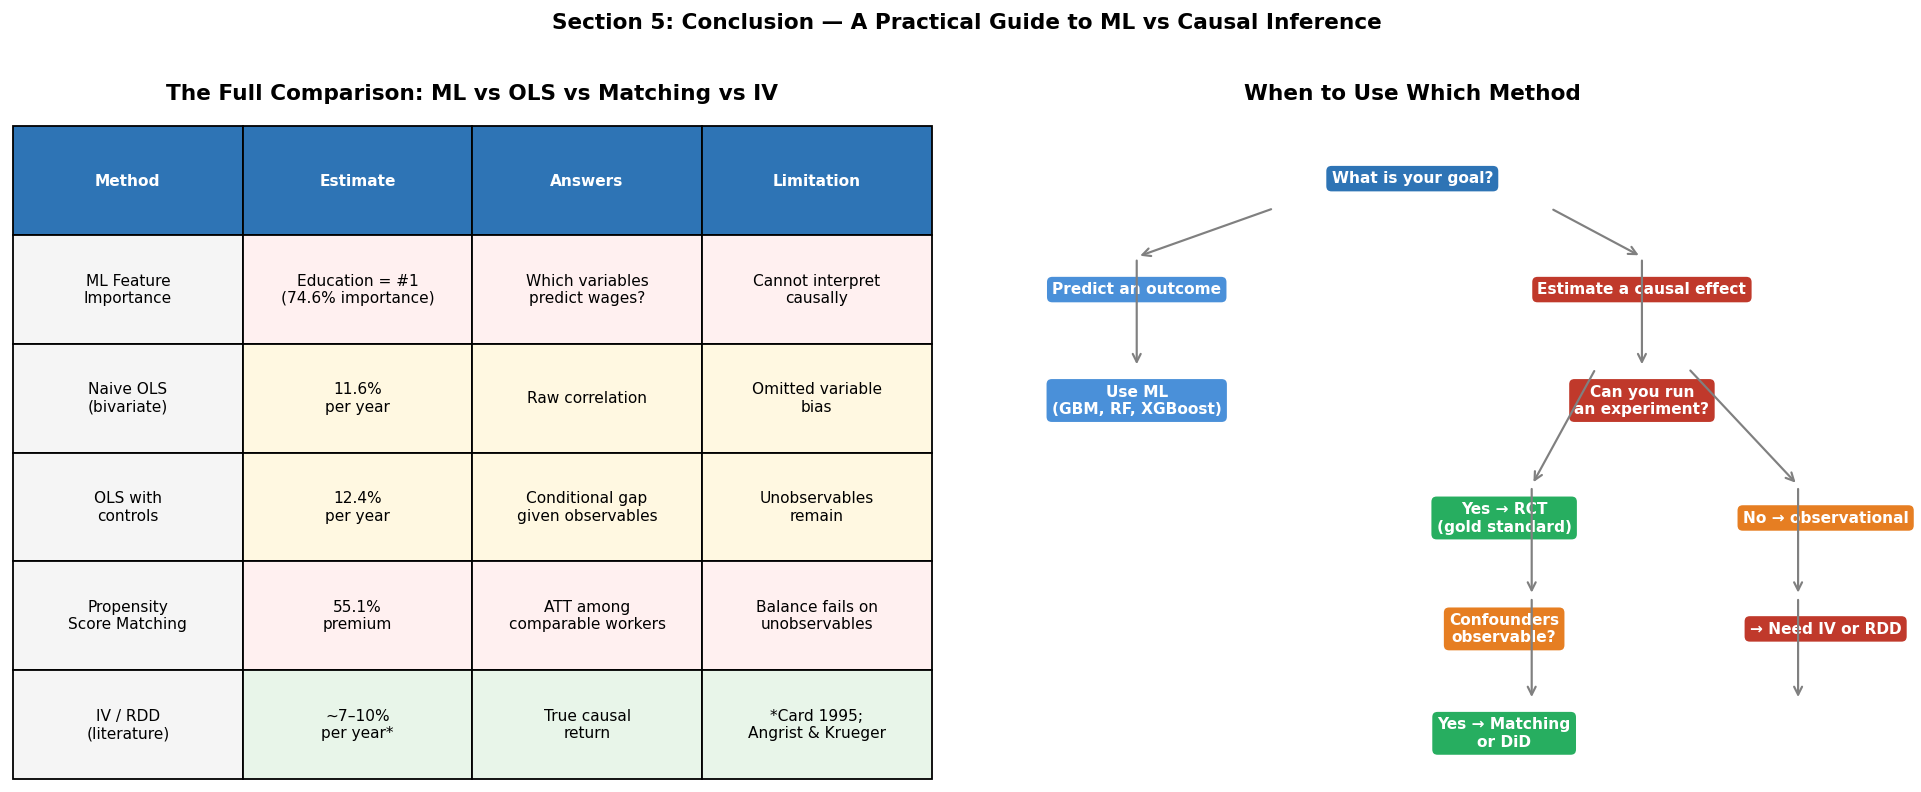


All figures saved to figures/
Done.


In [7]:
# ── Summary visualization ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Table: full method comparison
ax1 = axes[0]
ax1.axis('off')

table_data = [
    ['Method', 'Estimate', 'Answers', 'Limitation'],
    ['ML Feature\nImportance', f'Education = #1\n({importances["educ_years"]*100:.1f}% importance)',
     'Which variables\npredict wages?', 'Cannot interpret\ncausally'],
    ['Naive OLS\n(bivariate)', f'{m1.params["educ_years"]*100:.1f}%\nper year',
     'Raw correlation', 'Omitted variable\nbias'],
    ['OLS with\ncontrols', f'{m3.params["educ_years"]*100:.1f}%\nper year',
     'Conditional gap\ngiven observables', 'Unobservables\nremain'],
    ['Propensity\nScore Matching', f'{att*100:.1f}%\npremium',
     'ATT among\ncomparable workers', 'Balance fails on\nunobservables'],
    ['IV / RDD\n(literature)', '~7–10%\nper year*',
     'True causal\nreturn', '*Card 1995;\nAngrist & Krueger'],
]

row_colors = [
    ['#2E74B5'] * 4,
    ['#f5f5f5', '#fff0f0', '#fff0f0', '#fff0f0'],
    ['#f5f5f5', '#fff8e1', '#fff8e1', '#fff8e1'],
    ['#f5f5f5', '#fff8e1', '#fff8e1', '#fff8e1'],
    ['#f5f5f5', '#fff0f0', '#fff0f0', '#fff0f0'],
    ['#f5f5f5', '#e8f5e9', '#e8f5e9', '#e8f5e9'],
]

table = ax1.table(
    cellText=table_data[1:],
    colLabels=table_data[0],
    cellColours=row_colors[1:],
    colColours=row_colors[0],
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
for j in range(4):
    table[0, j].set_text_props(color='white', fontweight='bold')
ax1.set_title('The Full Comparison: ML vs OLS vs Matching vs IV', fontweight='bold', pad=15)

# Decision guide
ax2 = axes[1]
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 10)
ax2.set_title('When to Use Which Method', fontweight='bold', pad=15)

decision_boxes = [
    (5,   9.2, 'What is your goal?',              '#2E74B5'),
    (2,   7.5, 'Predict an outcome',               '#4A90D9'),
    (7.5, 7.5, 'Estimate a causal effect',         '#C0392B'),
    (2,   5.8, 'Use ML\n(GBM, RF, XGBoost)',       '#4A90D9'),
    (7.5, 5.8, 'Can you run\nan experiment?',      '#C0392B'),
    (6,   4.0, 'Yes → RCT\n(gold standard)',       '#27AE60'),
    (9.5, 4.0, 'No → observational',               '#E67E22'),
    (6,   2.3, 'Confounders\nobservable?',         '#E67E22'),
    (9.5, 2.3, '→ Need IV or RDD',                 '#C0392B'),
    (6,   0.7, 'Yes → Matching\nor DiD',           '#27AE60'),
]
for (x, y, text, fc) in decision_boxes:
    ax2.text(x, y, text, ha='center', va='center', fontsize=8.5,
             fontweight='bold', color='white',
             bbox=dict(boxstyle='round,pad=0.4', facecolor=fc, edgecolor='white', linewidth=1))

arrow_style = dict(arrowstyle='->', color='gray', lw=1.2)
for xy, xytext in [
    ((2, 8.0), (3.5, 8.75)), ((7.5, 8.0), (6.5, 8.75)),
    ((2, 6.3), (2, 8.0)),    ((7.5, 6.3), (7.5, 8.0)),
    ((6.3, 4.5), (7.0, 6.3)), ((9.2, 4.5), (8.0, 6.3)),
    ((6.3, 2.8), (6.3, 4.5)), ((9.2, 2.8), (9.2, 4.5)),
    ((6.3, 1.2), (6.3, 2.8)), ((9.2, 1.2), (9.2, 2.8)),
]:
    ax2.annotate('', xy=xy, xytext=xytext, arrowprops=arrow_style)

plt.suptitle('Section 5: Conclusion — A Practical Guide to ML vs Causal Inference',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figures/section5_conclusion.png', bbox_inches='tight', dpi=130)
plt.show()

print("\nAll figures saved to figures/")
print("Done.")